# MSDM 5002 HW4

Author：    LAN Tianwei 藍天蔚<br>
ID：        21230969<br>
Email：     tlanaa@connect.ust.hk<br>

# Q1: Coin Toss Rainbow

## Part a: `draw_rainbow()` function

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

def draw_rainbow():
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 28)
    ax.set_ylim(0, 16)
    center = (14, 2)
    width = 3
    colors = ['#FF3333', '#FFFF33', '#00994D', '#3399FF']

    for i in range(4):
        outer_radius = (4 - i) * width
        inner_radius = (3 - i) * width
        w = width if i < 3 else outer_radius
        ax.add_patch(Wedge(center, outer_radius, 0, 180, width=w, facecolor=colors[i], edgecolor='#000000', linewidth=1))

    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return(ax)

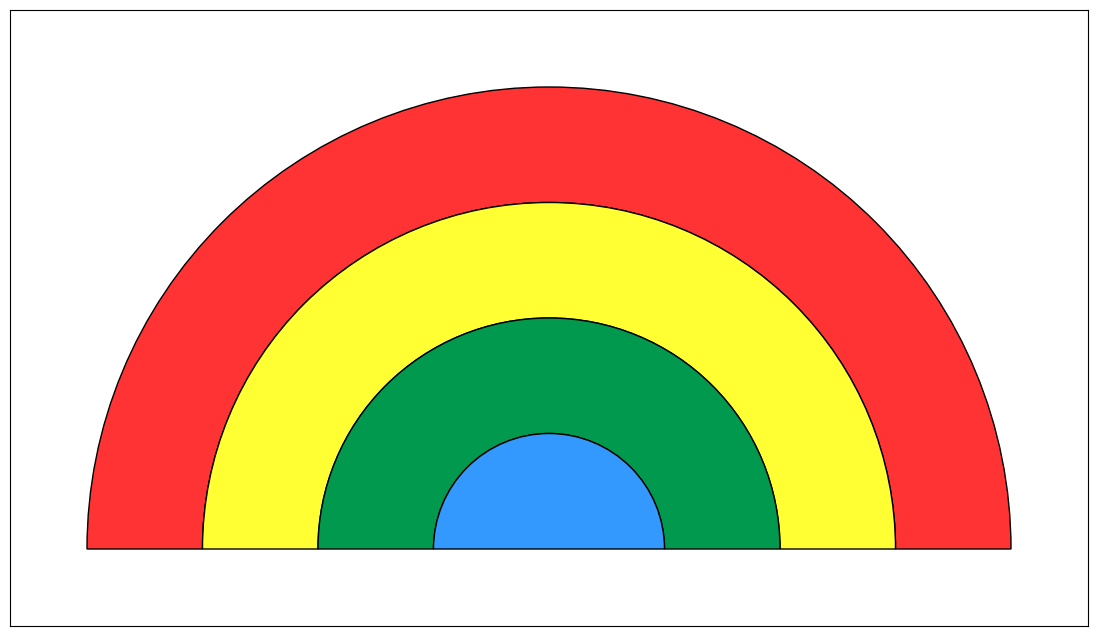

In [ ]:
draw_rainbow()
plt.show()

## Part b: `toss_result()` function

In [36]:
from math import sqrt

def toss_result(x, y):
    cx, cy = 14, 2
    d = sqrt((x - cx)**2 + (y - cy)**2)
    r_coin = 1
    layers = [(12, 9, 'Red'),
              (9, 6, 'Yellow'), 
              (6, 3, 'Green'),
              (3, 0, 'Blue')]
    for R, r, color in layers:
        if d + r_coin <= R and d - r_coin >= r:
            return color
    return "Failed"

In [45]:
print(toss_result(14,3))
print(toss_result(14,6))
print(toss_result(4,3))

Blue
Green
Red


## Part c: `toss_rainbow()` function

In [113]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

def toss_rainbow(coin_x, coin_y):
    ax = draw_rainbow()
    result = toss_result(coin_x, coin_y)
    ax.add_patch(Circle((coin_x, coin_y), 1, facecolor='#EEEEEE', edgecolor='black', linewidth=1))
    ax.text(27, 15, result, fontsize=30, ha='right', va='top')
    plt.savefig("toss_rainbow.png")
    plt.show()

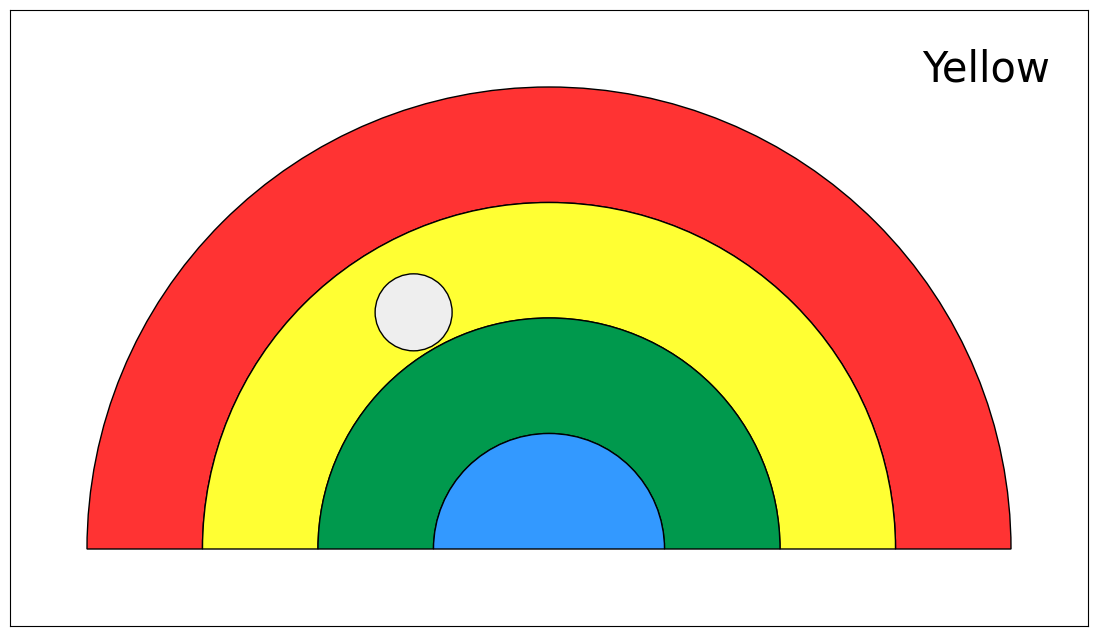

In [114]:
import random
x = random.uniform(1, 27)
y = random.uniform(1, 15)
toss_rainbow(x, y)

# Q2: Midpoint Polygon Iteration Animation

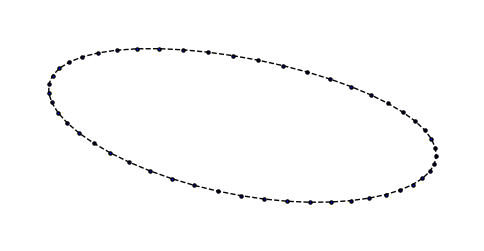

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

n = 50
points = np.random.rand(n, 2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

line, = ax.plot([], [], 'k--', linewidth=1)
scatter = ax.scatter([], [], c='#0000FF', edgecolors='black', s=5)

def update(frame):
    global points
    for _ in range(5):
        new_points = np.zeros_like(points)
        for i in range(n - 1):
            new_points[i] = (points[i] + points[i + 1]) / 2
        new_points[n - 1] = (points[n - 1] + points[0]) / 2
        points = new_points

    line.set_data(np.append(points[:, 0], points[0, 0]),
                  np.append(points[:, 1], points[0, 1]))
    scatter.set_offsets(points)

    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    margin = max(x_max - x_min, y_max - y_min) * 0.1
    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)

ani = animation.FuncAnimation(fig, update, frames=100, interval=200, repeat=True)
ani.save('polygon_animation.gif',writer='pillow', fps=60)
plt.show()

# Q3: Mincraft Village Style Wooden House 

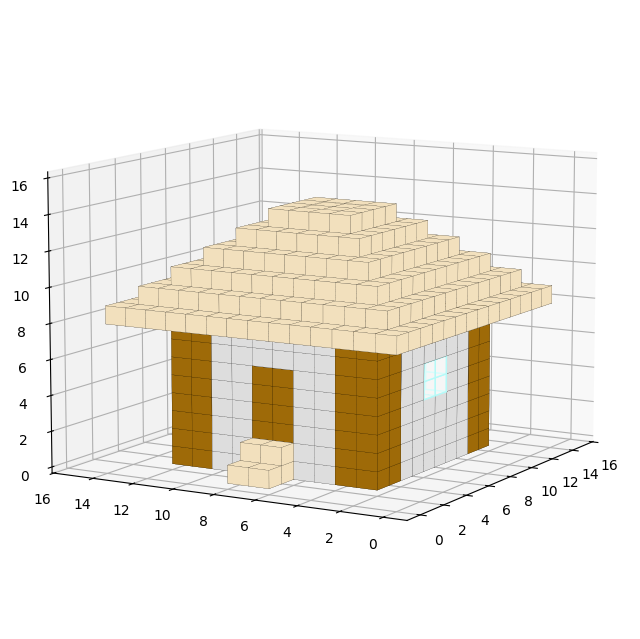

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create Space
space = np.zeros((15, 15, 16), dtype=bool)

# Color
WALL_COLOR = '#DDDDDD'
PILLAR_DOOR_COLOR = '#9e6a08'
ROOF_STAIRS_COLOR = '#f2e0bd'

space[2:11, 2, 0:8]  = True  # front wall
space[2:11, 11, 0:8] = True  # back  wall
space[2, 2:11, 0:8]  = True  # left  wall
space[11, 2:11, 0:8] = True  # right wall

space[2, 6:8, 2:6] = False # door
space[6:8, 2, 4:6] = False # window

# pillars
space[2:4, 2:4, 0:8]     = False
space[10:12, 2:4, 0:8]   = False
space[2:4, 10:12, 0:8]   = False
space[10:12, 10:12, 0:8] = False


fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(projection='3d')

# walls
ax.voxels(space, facecolors=WALL_COLOR, edgecolors='k', shade=False, linewidth = 0.1)

# pillars and doors mask
pillar_door_mask = np.zeros_like(space)
pillar_door_mask[2:4, 2:4, 0:8]     = True
pillar_door_mask[10:12, 2:4, 0:8]   = True
pillar_door_mask[2:4, 10:12, 0:8]   = True
pillar_door_mask[10:12, 10:12, 0:8] = True
pillar_door_mask[2, 6:8, 2:6]       = True
ax.voxels(pillar_door_mask, facecolors=PILLAR_DOOR_COLOR, edgecolors='k', shade=False, linewidth = 0.1)

# stairs mask
stairs_mask = np.zeros_like(space)
stairs_mask[0:2, 6:8, 0] = True
stairs_mask[1:2, 6:8, 1] = True
ax.voxels(stairs_mask, facecolors=ROOF_STAIRS_COLOR, edgecolors='k', shade=False, linewidth = 0.1)

# rooftop
roof_mask = np.zeros_like(space)
for level in range(8, 14):
    size = 14 - (level - 8) * 2
    if size <= 0:
        break
    start = (15 - size) // 2
    end = start + size
    roof_mask[start:end, start:end, level] = True
ax.voxels(roof_mask, facecolors=ROOF_STAIRS_COLOR, edgecolors='k', shade=False, linewidth = 0.1)

# windows
window_mask = np.zeros_like(space)
window_mask[6:8, 2, 4:6] = True
ax.voxels(window_mask, facecolors='#FFFFFF', edgecolors='#b6faf8',
          alpha=0.5, linewidth=1, shade=False)

ax.view_init(elev=10, azim=-150)
plt.savefig("voxel_house.png")
plt.show()

# Q4: DVD Icon Animation

## Part a：

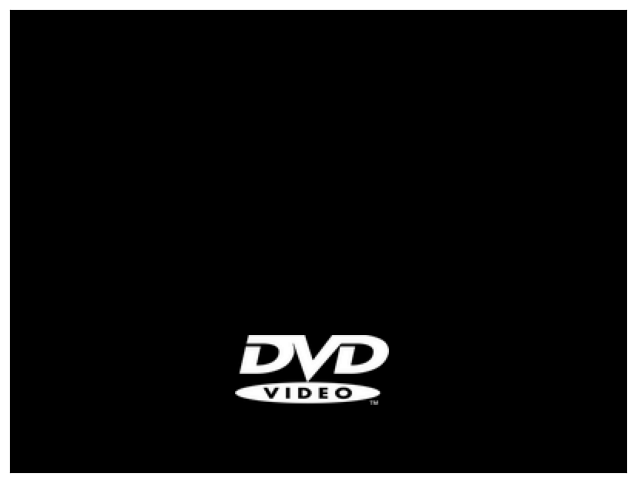

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image
import random

img = Image.open("DVD_logo.png").convert("RGBA")
img = img.resize((100, int(img.height * 100 / img.width)), Image.Resampling.LANCZOS)
data = np.array(img)
data[:, :, :3] = 255

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 4)
ax.set_ylim(0, 3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('black')
fig.patch.set_facecolor('white')

h, w = data.shape[:2]
half_w, half_h = w / 200, h / 200

x = random.uniform(half_w, 4 - half_w)
y = random.uniform(half_h, 3 - half_h)

vx, vy = 0.02, 0.02

extent = [x - half_w, x + half_w, y - half_h, y + half_h]
im = ax.imshow(data, extent=extent)

def update(frame):
    global x, y, vx, vy, extent
    x += vx
    y += vy

    if x - half_w <= 0 or x + half_w >= 4:
        vx = -vx
    if y - half_h <= 0 or y + half_h >= 3:
        vy = -vy

    extent = [x - half_w, x + half_w, y - half_h, y + half_h]
    im.set_extent(extent)
    return [im]

ani = FuncAnimation(fig, update, frames=1000, interval=20, blit=True)
ani.save('dvd_bounce.gif', writer='pillow', fps=60)
plt.show()

## Part b:

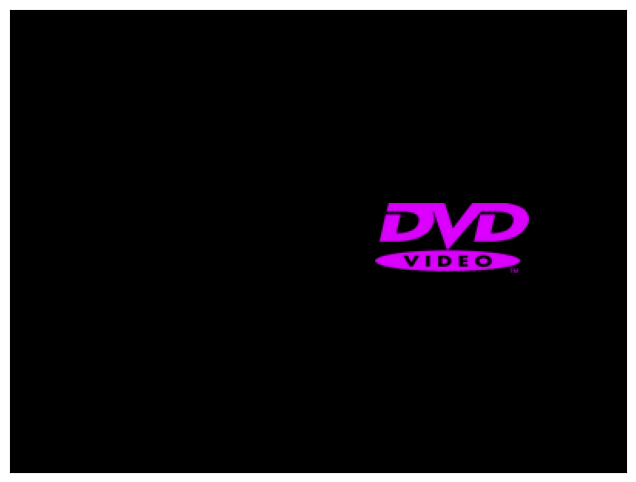

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image, ImageOps
import random
import colorsys

def make_logo(hue):
    r, g, b = colorsys.hsv_to_rgb(hue, 1, 1)
    rgb = (np.array([r, g, b]) * 255).astype(np.uint8)
    base = img_white.copy()
    color_layer = np.zeros_like(base[:, :, :3])
    color_layer[:, :, :] = rgb.reshape(1, 1, 3)
    new_rgb = color_layer
    return np.dstack((new_rgb, base[:, :, 3]))


img = Image.open("DVD_logo.png").convert("RGBA")
img = img.resize((100, int(img.height * 100 / img.width)), Image.Resampling.LANCZOS)
img_white = np.array(img)
img_white[:, :, :3] = 255
data = np.array(img_white)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 4); ax.set_ylim(0, 3)
ax.set_xticks([]); ax.set_yticks([])
ax.set_facecolor('black')
fig.patch.set_facecolor('white')

h, w = data.shape[:2]
half_w, half_h = w / 200, h / 200
x = random.uniform(half_w, 4 - half_w)
y = random.uniform(half_h, 3 - half_h)
vx = vy = 0.02

extent = [x - half_w, x + half_w, y - half_h, y + half_h]
im = ax.imshow(data, extent=extent)

def update(frame):
    global x, y, vx, vy, extent
    x += vx
    y += vy
    bounced = False
    if x - half_w <= 0 or x + half_w >= 4:
        vx = -vx
        bounced = True
    if y - half_h <= 0 or y + half_h >= 3:
        vy = -vy
        bounced = True
    if bounced:
        im.set_array(make_logo(random.random()))  # 换色
    extent = [x - half_w, x + half_w, y - half_h, y + half_h]
    im.set_extent(extent)
    return [im]

ani = FuncAnimation(fig, update, frames=1000, interval=20, blit=True)
ani.save('dvd_bounce_color.gif', writer='pillow', fps=60)
plt.show()